In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
#load dataset
df = pd.read_csv(r"C:\Users\USER\adidas-sales-intelligence-project\data\adidas_sales.csv")
df.head()

,Retailer_ID,Retailer,Invoice_Date,Region,State,City,Product,Price_per_Unit,Units_Sold,Total_Sales,Operating_Profit,Operating_Margin,Sales_Method
0,1185732,Foot Locker,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50,1200,600000,300000,50%,In-store
1,1185732,Foot Locker,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50,1000,500000,150000,30%,In-store
2,1185732,Foot Locker,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40,1000,400000,140000,35%,In-store
3,1185732,Foot Locker,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45,850,382500,133875,35%,In-store
4,1185732,Foot Locker,2020-01-05,Northeast,New York,New York,Men's Apparel,60,900,540000,162000,30%,In-store


In [7]:
#check data
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Retailer_ID       9648 non-null   int64 
 1   Retailer          9648 non-null   object
 2   Invoice_Date      9648 non-null   object
 3   Region            9648 non-null   object
 4   State             9648 non-null   object
 5   City              9648 non-null   object
 6   Product           9648 non-null   object
 7   Price_per_Unit    9648 non-null   int64 
 8   Units_Sold        9648 non-null   int64 
 9   Total_Sales       9648 non-null   int64 
 10  Operating_Profit  9648 non-null   int64 
 11  Operating_Margin  9648 non-null   object
 12  Sales_Method      9648 non-null   object
dtypes: int64(5), object(8)
memory usage: 980.0+ KB


,Retailer_ID,Price_per_Unit,Units_Sold,Total_Sales,Operating_Profit
count,9.648000e+03,9648.000000,9648.000000,9648.000000,9648.000000
mean,1.173850e+06,45.216625,256.930037,93273.437500,34425.282131
std,2.636038e+04,14.705397,214.252030,141916.016727,54193.124141
min,1.128299e+06,7.000000,0.000000,0.000000,0.000000
25%,1.185732e+06,35.000000,106.000000,4254.500000,1922.000000
50%,1.185732e+06,45.000000,176.000000,9576.000000,4371.500000
75%,1.185732e+06,55.000000,350.000000,150000.000000,52063.000000
max,1.197831e+06,110.000000,1275.000000,825000.000000,390000.000000


In [8]:
#check missing values
df.isnull().sum()

Retailer_ID         0
Retailer            0
Invoice_Date        0
Region              0
State               0
City                0
Product             0
Price_per_Unit      0
Units_Sold          0
Total_Sales         0
Operating_Profit    0
Operating_Margin    0
Sales_Method        0
dtype: int64

In [14]:
#remove duplicates
df.drop_duplicates(inplace=True)


In [15]:
#convert date column datatype
df['Invoice_Date'] = pd.to_datetime(df['Invoice_Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer_ID       9648 non-null   int64         
 1   Retailer          9648 non-null   object        
 2   Invoice_Date      9648 non-null   datetime64[ns]
 3   Region            9648 non-null   object        
 4   State             9648 non-null   object        
 5   City              9648 non-null   object        
 6   Product           9648 non-null   object        
 7   Price_per_Unit    9648 non-null   int64         
 8   Units_Sold        9648 non-null   int64         
 9   Total_Sales       9648 non-null   int64         
 10  Operating_Profit  9648 non-null   int64         
 11  Operating_Margin  9648 non-null   object        
 12  Sales_Method      9648 non-null   object        
dtypes: datetime64[ns](1), int64(5), object(7)
memory usage: 980.0+ KB


In [20]:
#create profit margin
df['Profit_Margin'] = (df['Operating_Profit'] / df['Total_Sales']) * 100
df.head()

,Retailer_ID,Retailer,Invoice_Date,Region,State,City,Product,Price_per_Unit,Units_Sold,Total_Sales,Operating_Profit,Operating_Margin,Sales_Method,Profit_Margin
0,1185732,Foot Locker,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50,1200,600000,300000,50%,In-store,50.0
1,1185732,Foot Locker,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50,1000,500000,150000,30%,In-store,30.0
2,1185732,Foot Locker,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40,1000,400000,140000,35%,In-store,35.0
3,1185732,Foot Locker,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45,850,382500,133875,35%,In-store,35.0
4,1185732,Foot Locker,2020-01-05,Northeast,New York,New York,Men's Apparel,60,900,540000,162000,30%,In-store,30.0


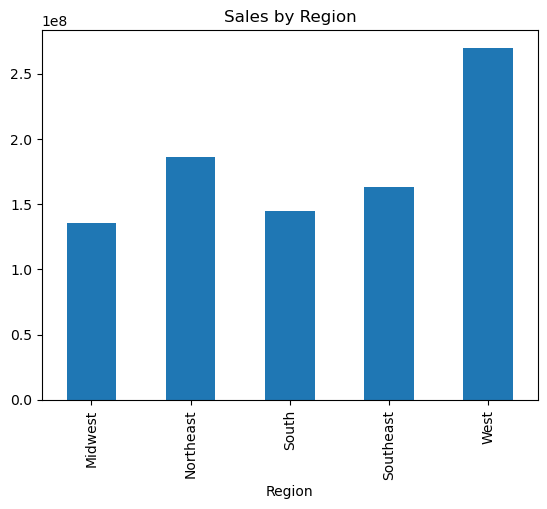

In [22]:
#sale by region
region_sales = df.groupby('Region')['Total_Sales'].sum()
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

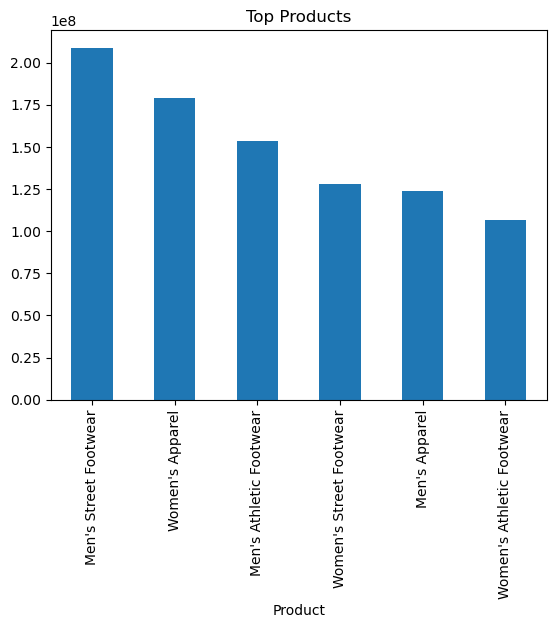

In [25]:
#Top Products
top_products = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)
top_products.head(10).plot(kind='bar')
plt.title("Top Products")
plt.show()

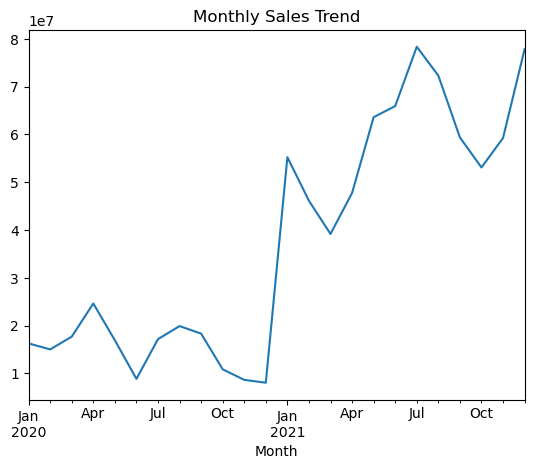

In [26]:
#monthly sales trend
df['Month'] = df['Invoice_Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total_Sales'].sum()
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()